<a href="https://colab.research.google.com/github/rohhitrz/AIML/blob/main/transformers_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔤 From Text to Attention

By the end of this notebook, you'll understand:
1. How text becomes tokens (and why it matters)
2. How tokens become meaningful vectors (embeddings)
3. How position information gets added
4. How attention actually works — coded from scratch

Let's start!

---
# Part 1: Tokenization
*What does the model actually see?*

---

In [1]:
# First, install tiktoken (OpenAI's tokenizer)
!pip install tiktoken -q

In [2]:
import tiktoken
import numpy as np

# GPT-4's tokenizer
tokenizer=tiktoken.get_encoding("cl100k_base")

print(f"vocabulary_size: {tokenizer.n_vocab: ,} tokens")



vocabulary_size:  100,277 tokens


In [3]:
text="Hello world"
tokens=tokenizer.encode(text)

print(f" the text is {text}")
print(f" the token is {tokens}")
print(f" Number of tokens: {len(tokens)}")

# Let's see what each token represents
for token in tokens:
  print(f" {token}-> '{tokenizer.decode([token])}' ")


 the text is Hello world
 the token is [9906, 1917]
 Number of tokens: 2
 9906-> 'Hello' 
 1917-> ' world' 


In [4]:
# Let's try more interesting examples
examples = [
    "Hello world",
    "don't",
    "artificial intelligence",
    "I love AI",
    "supercalifragilisticexpialidocious",
    "🚀",
    "café",
    "    spaces    ",  # multiple spaces
]

print("How different texts get tokenized:\n")
for text in examples:
  tokens= tokenizer.encode(text)
  print(f" '{text}'")
  print(f" -> {len(tokens)} tokens: {tokens}")

  # show the pieces

  pieces= [tokenizer.decode([t]) for t in tokens]
  print(f" -> pieces:{pieces}" )
  print()





How different texts get tokenized:

 'Hello world'
 -> 2 tokens: [9906, 1917]
 -> pieces:['Hello', ' world']

 'don't'
 -> 2 tokens: [15357, 956]
 -> pieces:['don', "'t"]

 'artificial intelligence'
 -> 3 tokens: [472, 16895, 11478]
 -> pieces:['art', 'ificial', ' intelligence']

 'I love AI'
 -> 3 tokens: [40, 3021, 15592]
 -> pieces:['I', ' love', ' AI']

 'supercalifragilisticexpialidocious'
 -> 11 tokens: [13066, 3035, 278, 333, 4193, 321, 4633, 4683, 532, 307, 78287]
 -> pieces:['sup', 'erc', 'al', 'if', 'rag', 'il', 'istic', 'exp', 'ial', 'id', 'ocious']

 '🚀'
 -> 3 tokens: [9468, 248, 222]
 -> pieces:['�', '�', '�']

 'café'
 -> 2 tokens: [936, 59958]
 -> pieces:['ca', 'fé']

 '    spaces    '
 -> 3 tokens: [262, 12908, 257]
 -> pieces:['   ', ' spaces', '    ']



## 🧪 Try It Yourself

Tokenize your own text! Try:
- Your name
- A sentence in another language
- Some code
- Emojis

In [5]:
text= "I am Rohit"

tokens=tokenizer.encode(text)
print(text)
print(tokens)
print(len(tokens))
print(f"pieces : {[tokenizer.decode([t]) for t in tokens]}")

I am Rohit
[40, 1097, 42087, 275]
4
pieces : ['I', ' am', ' Roh', 'it']


## 1.2 Why Tokenization Matters

Token count affects:
- API costs (you pay per token)
- Context limits (GPT-4 has 128K token limit)
- Model behavior (some tasks break across token boundaries)

In [6]:
# Compare token efficiency across different content types

test_cases = {
    "English prose": "The quick brown fox jumps over the lazy dog.",
    "Python code": "def hello():\n    print('Hello, world!')",
    "JSON": '{"name": "Alice", "age": 30, "city": "NYC"}',
    "Numbers": "1234567890 9876543210 1111111111",
    "URL": "https://www.example.com/path/to/page?query=value",
}

print("Token Efficiency Comparison: \n")
for name, text in test_cases.items():
  tokens=tokenizer.encode(text)
  chars=len(text)
  ratio=chars/len(tokens)
  print(f"{name}: ")
  print(f"  {chars} chars → {len(tokens)} tokens ({ratio:.1f} chars/token)")
  print()



Token Efficiency Comparison: 

English prose: 
  44 chars → 10 tokens (4.4 chars/token)

Python code: 
  39 chars → 11 tokens (3.5 chars/token)

JSON: 
  43 chars → 19 tokens (2.3 chars/token)

Numbers: 
  32 chars → 14 tokens (2.3 chars/token)

URL: 
  48 chars → 11 tokens (4.4 chars/token)



**Key insight**: Different content has different token efficiency.
- English prose: ~4 characters per token
- Code/JSON: often less efficient (more tokens per character)
- This affects your API costs!

## 1.3 The Token Boundary Problem

Some tasks are hard because they require reasoning WITHIN tokens.

In [7]:
# Why LLMs struggle with letter counting

word = "strawberry"

tokens=tokenizer.encode(word)
print(f"word: {word}")
print(f"Tokens: {tokens}")
print(f"pieces: {[tokenizer.decode([t]) for t in tokens]}")
print()
print("The model sees these pieces, not individual letters!")
print("Counting 'r's requires looking INSIDE tokens — that's hard.")

word: strawberry
Tokens: [496, 675, 15717]
pieces: ['str', 'aw', 'berry']

The model sees these pieces, not individual letters!
Counting 'r's requires looking INSIDE tokens — that's hard.


In [8]:
# Another example: reversing words

word = "hello"
tokens = tokenizer.encode(word)
print(f"tokens->{token}")
print(f"'{word}' → tokens{tokens}: {[tokenizer.decode([t]) for t in tokens]}")
print()
print("If 'hello' is ONE token, the model can't easily reverse it.")
print("It would need to decompose something it sees as atomic.")

tokens->1917
'hello' → tokens[15339]: ['hello']

If 'hello' is ONE token, the model can't easily reverse it.
It would need to decompose something it sees as atomic.


---
# Part 2: Embeddings
*Tokens as points in space*

---

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# We'll use a small pre-computed set of embeddings for demonstration
# In practice, you'd load these from a model

## 2.1 What's an Embedding?

An embedding converts a token ID into a vector of numbers.
Let's simulate this with random embeddings first, then use real ones.

In [10]:
# Simulating an embedding matrix

vocab_size=50000
embedding_dim=768  # GPT-2 size

# Random embedding matrix (in reality, this is LEARNED)
embedding_matrix=np.random.randn(vocab_size,embedding_dim) *0.02

print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"  → {vocab_size:,} tokens")
print(f"  → {embedding_dim} dimensions per token")
print(f"  → {vocab_size * embedding_dim:,} total parameters just for embeddings!")

Embedding matrix shape: (50000, 768)
  → 50,000 tokens
  → 768 dimensions per token
  → 38,400,000 total parameters just for embeddings!


In [11]:

# How Embedding Look-Up works

text="Hello World"
tokens=tokenizer.encode(text)

print(f"Text: '{text}'")
print(f"Token IDs: {tokens}")
print()

# Look up each token's embedding

for token_id in tokens:
  embedding=embedding_matrix[token_id]
  print(f"Token ID: {token_id}")
  print(f"Token {token_id} ('{tokenizer.decode([token_id])}')")
  print(f"  → Embedding shape: {embedding.shape}")
  print(f"  → First 10 values: {embedding[:10].round(3)}")
  print()


Text: 'Hello World'
Token IDs: [9906, 4435]

Token ID: 9906
Token 9906 ('Hello')
  → Embedding shape: (768,)
  → First 10 values: [ 0.02   0.003 -0.003 -0.008  0.008 -0.023 -0.01  -0.035 -0.02   0.008]

Token ID: 4435
Token 4435 (' World')
  → Embedding shape: (768,)
  → First 10 values: [-0.012  0.051 -0.022 -0.03  -0.005 -0.018  0.005  0.012 -0.024 -0.028]



## 2.2 Real Embeddings: Word Similarity

Let's use pre-trained word vectors to see embeddings in action.
We'll use Gensim's Word2Vec — classic but illustrative.

In [12]:
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 72.0 MB/s eta 0:00:00


In [13]:
import gensim.downloader as api
# Load pre-trained word vectors

print("Loading word vectors... (this takes ~1 minute)")
word_vectors= api.load("glove-wiki-gigaword-100")
print(f"Loaded! Vocabulary: {len(word_vectors):,} words")


Loading word vectors... (this takes ~1 minute)
[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded! Vocabulary: 400,000 words


In [14]:
# Find similar words

word = "king"
similar = word_vectors.most_similar(word, topn=10)
print(f"similar-> {similar}")

print(f"Words most similar to '{word}':\n")
for similar_word, score in similar:
    print(f"  {similar_word}: {score:.3f}")

similar-> [('prince', 0.7682328820228577), ('queen', 0.7507690787315369), ('son', 0.7020888328552246), ('brother', 0.6985775232315063), ('monarch', 0.6977890729904175), ('throne', 0.6919989585876465), ('kingdom', 0.6811409592628479), ('father', 0.6802029013633728), ('emperor', 0.6712858080863953), ('ii', 0.6676074266433716)]
Words most similar to 'king':

  prince: 0.768
  queen: 0.751
  son: 0.702
  brother: 0.699
  monarch: 0.698
  throne: 0.692
  kingdom: 0.681
  father: 0.680
  emperor: 0.671
  ii: 0.668


## 2.3 The Famous Analogy: King - Man + Woman = ?

In [17]:
# Vector arithmetic with words!

result = word_vectors.most_similar(
    positive=["king", "woman"],
    negative=['man'],
    topn=5

)

print("king - man + woman = ?\n")
for word,score in result:
  print(f"  {word}: {score:.3f}")

king - man + woman = ?

  queen: 0.770
  monarch: 0.684
  throne: 0.676
  daughter: 0.659
  princess: 0.652


In [18]:
# try more analogies

analogies=[
    (["paris", "germany"], ["france"], "paris - france + germany =?"),
    (["bigger", "cold"],  ["big"], "bigger - big + cold = ?"),
    ]

for positive, negative, description in analogies:
  result= word_vectors.most_similar(
      positive=positive,
      negative= negative,
      topn=3
  )

  for word, score in result:
    print(f" {word}: {score: .3f}")
  print()

 berlin:  0.885
 frankfurt:  0.799
 vienna:  0.768

 cooler:  0.688
 warmer:  0.685
 colder:  0.675



## 2.4 Visualizing Embedding Space

Embeddings are high-dimensional. Let's project to 2D to visualize.

In [23]:
# Get Embeddings for a set of related words

word_groups= {
    "royalty":  ["king", "queen", "prince", "princess", "royal", "throne"],
    "family": ["man", "woman", "boy", "girl", "father", "mother"],
    "animals": ["dog", "cat", "horse", "bird", "fish", "lion"],
    "tech": ["computer", "software", "internet", "digital", "data", "code"],
}

# Collect all word and their embedding

words=[]
embeddings=[]
colors=[]
color_map={"royalty": "purple", "family": "blue", "animals": "green", "tech": "red"}

for group, word_list in word_groups.items():
  for word in word_list:
    if word in word_vectors:
      words.append(word)
      embeddings.append(word_vectors[word])
      colors.append(color_map[group])

embeddings=np.array(embeddings)
print(f"Collected {len(words)} words, each with {embeddings.shape[1]} dimensions")



Collected 24 words, each with 100 dimensions


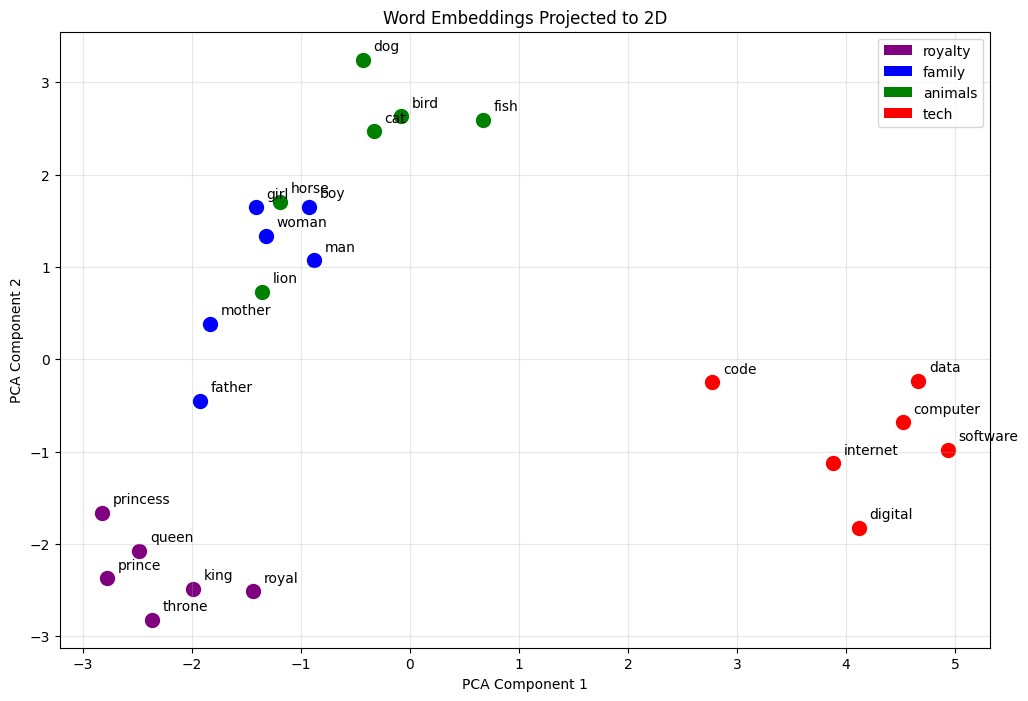

In [26]:
# Reduce to 2D PCA

pca= PCA(n_components=2)
embeddings_2d= pca.fit_transform(embeddings)

#plot
plt.figure(figsize=(12, 8))
for i, word in enumerate(words):
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], c=colors[i], s=100)
    plt.annotate(word, (embeddings_2d[i, 0] + 0.1, embeddings_2d[i, 1] + 0.1))

plt.title("Word Embeddings Projected to 2D")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=g) for g, c in color_map.items()]
plt.legend(handles=legend_elements)
plt.grid(True, alpha=0.3)
plt.show()

Notice how words cluster by meaning!
- Royalty words are near each other
- Family words form another cluster
- This structure emerges from training, not manual design

---
# ✅ Checkpoint: Embeddings Complete

You now understand:
- Token ID → Embedding vector (lookup in a matrix)
- Similar meanings = nearby vectors
- Analogies work through vector arithmetic
- Embedding space has meaningful structure

**→ Back to slides for Positional Encoding**

---

---
# Part 3: Positional Encoding
*Injecting word order*

---

## 3.1 The Problem: Attention Loses Order

Let's see why we need positional encoding.